# Final Plots

Publication-quality figures from LME results.

| Figure | File | Source |
|--------|------|--------|
| 1 | `figures/fig1_daic_by_predictor.svg` | `lme_results/lme_results.csv` |
| 2 | `figures/fig2_layer_depth_profile.svg` | `lme_results/lme_layer_results.csv` |
| 3 | `figures/fig3_scale_plot.svg` | `lme_results/lme_results.csv` |

In [25]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns

warnings.filterwarnings('ignore')

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

sns.set_theme(style='ticks', context='paper', font_scale=1.1)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

# ── Model metadata ────────────────────────────────────────────────────────────
PARAM_COUNTS = {
    'gpt2':                              117e6,
    'gpt2_large':                        774e6,
    'gpt2_xl':                          1558e6,
    'eleutherai_pythia_410m_deduped':    410e6,
    'eleutherai_pythia_1.4b_deduped':   1400e6,
    'eleutherai_pythia_2.8b_deduped':   2800e6,
    'eleutherai_pythia_6.9b_deduped':   6900e6,
    'eleutherai_pythia_12b_deduped':   12000e6,
    'qwen_qwen3_0.6b_base':              600e6,
    'qwen_qwen3_0.6b':                   600e6,
    'qwen_qwen3_1.7b_base':             1700e6,
    'qwen_qwen3_1.7b':                  1700e6,
    'qwen_qwen3_4b_base':               4000e6,
    'qwen_qwen3_4b':                    4000e6,
    'qwen_qwen3_8b_base':               8000e6,
    'qwen_qwen3_8b':                    8000e6,
    'qwen_qwen3_14b_base':             14000e6,
    'qwen_qwen3_14b':                  14000e6,
}

MODEL_LABELS = {
    'gpt2':                            'GPT-2',
    'gpt2_large':                      'GPT-2 L',
    'gpt2_xl':                         'GPT-2 XL',
    'eleutherai_pythia_410m_deduped':  'Py-410M',
    'eleutherai_pythia_1.4b_deduped':  'Py-1.4B',
    'eleutherai_pythia_2.8b_deduped':  'Py-2.8B',
    'eleutherai_pythia_6.9b_deduped':  'Py-6.9B',
    'eleutherai_pythia_12b_deduped':   'Py-12B',
    'qwen_qwen3_0.6b_base':            'Q3-0.6B (b)',
    'qwen_qwen3_0.6b':                 'Q3-0.6B',
    'qwen_qwen3_1.7b_base':            'Q3-1.7B (b)',
    'qwen_qwen3_1.7b':                 'Q3-1.7B',
    'qwen_qwen3_4b_base':              'Q3-4B (b)',
    'qwen_qwen3_4b':                   'Q3-4B',
    'qwen_qwen3_8b_base':              'Q3-8B (b)',
    'qwen_qwen3_8b':                   'Q3-8B',
    'qwen_qwen3_14b_base':             'Q3-14B (b)',
    'qwen_qwen3_14b':                  'Q3-14B',
}

FAMILY_PALETTE = {'GPT-2': '#2166ac', 'Pythia': '#d6604d', 'Qwen3': '#762a83'}
FAMILY_ORDER   = ['GPT-2', 'Pythia', 'Qwen3']

PREDICTOR_LABELS = {
    'last_layer_surprisal': 'Surprisal',
    'cv_layer_surprisal':   '(Best) Layer-wise surprisal',
    'shallow_surprisal':    'Shallow surprisal',
    'lang_mae_z':           'Language network updates',
    'su_sgm_z':             'Sentence gestalt layer update',
}
PREDICTOR_ORDER = list(PREDICTOR_LABELS.keys())

def get_family(model: str) -> str:
    if model.startswith('gpt2'):       return 'GPT-2'
    if model.startswith('eleutherai'): return 'Pythia'
    return 'Qwen3'

def get_model_type(model: str, family: str) -> str:
    if family in ('GPT-2', 'Pythia'): return 'base'
    return 'base' if model.endswith('_base') else 'instruct'

def save_fig(name: str) -> None:
    path = FIGURES_DIR / f'{name}.svg'
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved {path}')

# ── Load & annotate ───────────────────────────────────────────────────────────
results       = pd.read_csv('lme_results/lme_results.csv')
layer_results = pd.read_csv('lme_results/lme_layer_results.csv')

for df in (results, layer_results):
    df['family']       = df['model'].map(get_family)
    df['param_count']  = df['model'].map(PARAM_COUNTS)
    df['model_label']  = df['model'].map(MODEL_LABELS)
    df['family_order'] = df['family'].map({f: i for i, f in enumerate(FAMILY_ORDER)})

results['model_type'] = results.apply(
    lambda r: get_model_type(r['model'], r['family']), axis=1)

results       = results.sort_values(['family_order', 'param_count']).reset_index(drop=True)
layer_results = layer_results.sort_values(['family_order', 'param_count']).reset_index(drop=True)

MODEL_ORDER = results['model'].unique().tolist()

# Sanity checks
print(f"results shape:       {results.shape}")
print(f"layer_results shape: {layer_results.shape}")
missing = [m for m in MODEL_ORDER if m not in PARAM_COUNTS]
print(f"Models missing from PARAM_COUNTS: {missing or 'none'}")
print()
print(results.drop_duplicates('model')[
    ['model', 'family', 'model_type', 'param_count', 'model_label']
].to_string(index=False))

results shape:       (80, 14)
layer_results shape: (244, 15)
Models missing from PARAM_COUNTS: none

                         model family model_type  param_count model_label
                          gpt2  GPT-2       base 1.170000e+08       GPT-2
                    gpt2_large  GPT-2       base 7.740000e+08     GPT-2 L
                       gpt2_xl  GPT-2       base 1.558000e+09    GPT-2 XL
eleutherai_pythia_410m_deduped Pythia       base 4.100000e+08     Py-410M
eleutherai_pythia_1.4b_deduped Pythia       base 1.400000e+09     Py-1.4B
eleutherai_pythia_2.8b_deduped Pythia       base 2.800000e+09     Py-2.8B
eleutherai_pythia_6.9b_deduped Pythia       base 6.900000e+09     Py-6.9B
 eleutherai_pythia_12b_deduped Pythia       base 1.200000e+10      Py-12B
          qwen_qwen3_0.6b_base  Qwen3       base 6.000000e+08 Q3-0.6B (b)
               qwen_qwen3_0.6b  Qwen3   instruct 6.000000e+08     Q3-0.6B
          qwen_qwen3_1.7b_base  Qwen3       base 1.700000e+09 Q3-1.7B (b)
           

## Figure 1: ΔAIC by predictor

Five panels — one per predictor. Models sorted left-to-right by family (GPT-2 → Pythia → Qwen3) then parameter count. Grey bars = models that lack this predictor (e.g. Qwen3 has no CV layer surprisal).

Saved figures/fig1_daic_by_predictor.svg


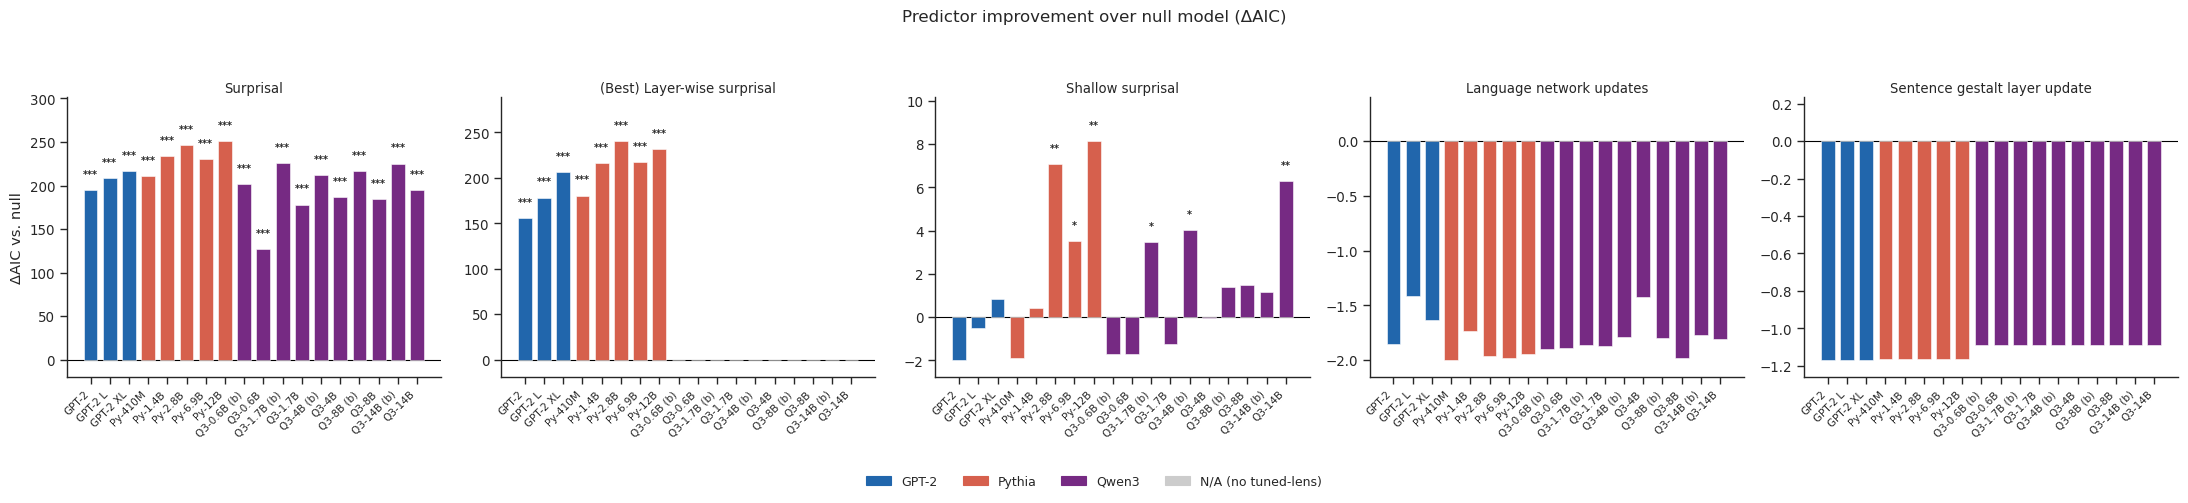

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)

for ax, predictor in zip(axes, PREDICTOR_ORDER):
    pred_data = (
        results[results['predictor'] == predictor]
        .sort_values(['family_order', 'param_count'])
        .reset_index(drop=True)
    )

    all_models_df = (
        results.drop_duplicates('model')
        .sort_values(['family_order', 'param_count'])
        .reset_index(drop=True)[['model', 'family', 'family_order',
                                  'param_count', 'model_label']]
    )
    panel_df = all_models_df.merge(
        pred_data[['model', 'daic', 'sig']], on='model', how='left')

    colors = [
        FAMILY_PALETTE[get_family(m)] if pd.notna(daic) else '#cccccc'
        for m, daic in zip(panel_df['model'], panel_df['daic'])
    ]
    x_pos = np.arange(len(panel_df))

    ax.bar(x_pos, panel_df['daic'].fillna(0), color=colors,
           width=0.72, edgecolor='white', linewidth=0.4)

    y_vals  = panel_df['daic'].fillna(0)
    y_lo    = min(y_vals.min(), 0)
    y_hi    = max(y_vals.max(), 0)
    y_range = max(y_hi - y_lo, 1.0)
    ax.set_ylim(y_lo - y_range * 0.08, y_hi + y_range * 0.20)
    star_offset = y_range * 0.05

    for xi, row in enumerate(panel_df.itertuples()):
        sig_str = str(row.sig) if pd.notna(row.sig) else ''
        if pd.notna(row.daic) and sig_str.strip():
            y_pos = row.daic + star_offset if row.daic >= 0 else row.daic - star_offset
            va    = 'bottom' if row.daic >= 0 else 'top'
            ax.text(xi, y_pos, sig_str, ha='center', va=va,
                    fontsize=7, fontweight='bold')

    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, zorder=0)
    ax.set_title(PREDICTOR_LABELS[predictor], fontsize=9.5, pad=4)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        [MODEL_LABELS.get(m, m) for m in panel_df['model']],
        rotation=45, ha='right', fontsize=7.5)
    if ax is axes[0]:
        ax.set_ylabel('ΔAIC vs. null')
    sns.despine(ax=ax)

# Legend centred below all subplots — avoids crowding the rightmost panel
patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_PALETTE.items()]
patches.append(mpatches.Patch(color='#cccccc', label='N/A (no tuned-lens)'))
fig.legend(handles=patches, loc='lower center',
           bbox_to_anchor=(0.5, 0.0), ncol=4, frameon=False, fontsize=9)

fig.suptitle('Predictor improvement over null model (ΔAIC)', fontsize=12)
# rect bottom reserves space for the legend row; top for the suptitle
plt.tight_layout(rect=[0, 0.09, 1, 0.93])
save_fig('fig1_daic_by_predictor')
plt.show()

## Figure 2: Layer-depth profile

ΔAIC vs. relative layer depth for GPT-2 and Pythia models. Lighter shade = smaller model within each family.

Saved figures/fig2_layer_depth_profile.svg


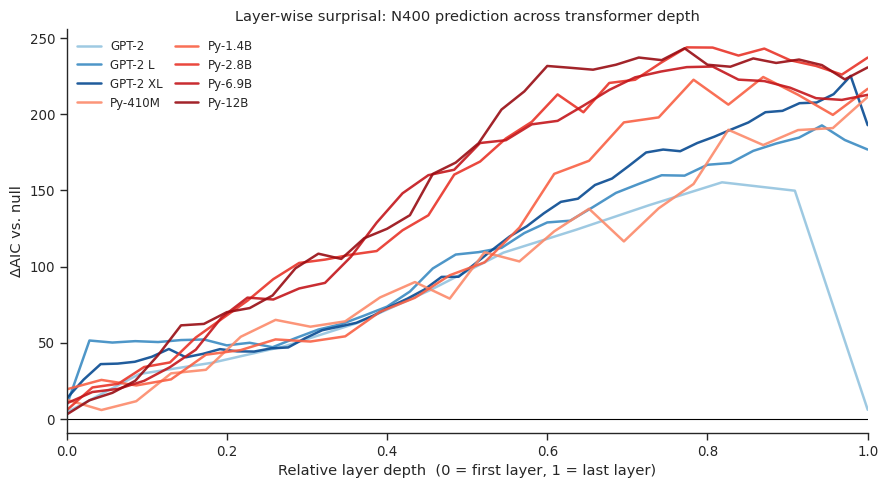

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

gpt2_models   = sorted([m for m in layer_results['model'].unique()
                         if get_family(m) == 'GPT-2'],
                        key=lambda m: PARAM_COUNTS[m])
pythia_models = sorted([m for m in layer_results['model'].unique()
                         if get_family(m) == 'Pythia'],
                        key=lambda m: PARAM_COUNTS[m])

gpt2_colors   = plt.cm.Blues(np.linspace(0.40, 0.90, max(len(gpt2_models), 1)))
pythia_colors = plt.cm.Reds( np.linspace(0.40, 0.90, max(len(pythia_models), 1)))

color_map = {**dict(zip(gpt2_models, gpt2_colors)),
             **dict(zip(pythia_models, pythia_colors))}

for model in gpt2_models + pythia_models:
    mdf   = layer_results[layer_results['model'] == model].sort_values('layer_pct')
    label = MODEL_LABELS.get(model, model)
    ax.plot(mdf['layer_pct'], mdf['daic'],
            color=color_map[model], linewidth=1.8, alpha=0.9, label=label)

ax.axhline(0, color='black', linestyle='-', linewidth=0.8, zorder=0)
ax.set_xlabel('Relative layer depth  (0 = first layer, 1 = last layer)')
ax.set_ylabel('ΔAIC vs. null')
ax.set_title('Layer-wise surprisal: N400 prediction across transformer depth')
ax.set_xlim(0, 1)

ax.legend(loc='upper left', frameon=False, fontsize=8.5, ncol=2, columnspacing=1)
sns.despine(ax=ax)
plt.tight_layout()
save_fig('fig2_layer_depth_profile')
plt.show()

## Figure 3: Scale plot

ΔAIC for `last_layer_surprisal` vs. parameter count (log scale).  
Color = model family; **○** = base, **△** = instruct (Qwen3 only).

Saved figures/fig3_scale_plot.svg


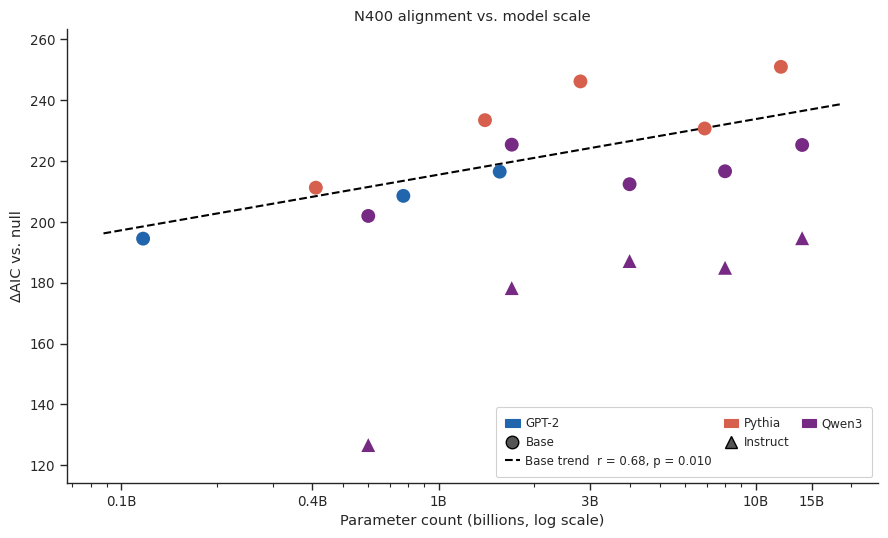

In [33]:
from matplotlib.lines import Line2D
from scipy import stats

scale = results[results['predictor'] == 'last_layer_surprisal'].copy()
scale['params_B'] = scale['param_count'] / 1e9

fig, ax = plt.subplots(figsize=(9, 5.5))

# Scatter — base (○) and instruct (△)
marker_map = {'base': 'o', 'instruct': '^'}
for family in FAMILY_ORDER:
    for mtype, marker in marker_map.items():
        sub = scale[(scale['family'] == family) & (scale['model_type'] == mtype)]
        if sub.empty:
            continue
        ax.scatter(sub['params_B'], sub['daic'],
                   color=FAMILY_PALETTE[family], marker=marker,
                   s=100, zorder=3, edgecolors='none')

# Log-linear trend for base models only
base_data = scale[scale['model_type'] == 'base'].dropna(subset=['daic'])
slope, intercept, r, p_val, _ = stats.linregress(
    np.log10(base_data['params_B']), base_data['daic'])
x_lo = base_data['params_B'].min() * 0.75
x_hi = base_data['params_B'].max() * 1.33
x_fit = np.logspace(np.log10(x_lo), np.log10(x_hi), 300)
ax.plot(x_fit, slope * np.log10(x_fit) + intercept,
        color='black', linewidth=1.5, linestyle='--', zorder=2)

ax.axhline(0, color='black', linestyle='-', linewidth=0.8, zorder=0)
ax.set_xscale('log')
ax.set_xlabel('Parameter count (billions, log scale)')
ax.set_ylabel('ΔAIC vs. null')
ax.set_title('N400 alignment vs. model scale')

y_vals = scale['daic'].dropna()
y_lo, y_hi = y_vals.min(), y_vals.max()
pad = (y_hi - y_lo) * 0.10
ax.set_ylim(y_lo - pad, y_hi + pad)

xticks = [0.1, 0.4, 1, 3, 10, 15]
ax.set_xticks(xticks)
ax.set_xticklabels([f'{x:g}B' for x in xticks])
ax.xaxis.set_minor_locator(ticker.LogLocator(subs='all', numticks=10))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

# Three-column inset legend (lower-right).
# ncol=3 fills row-by-row, so handles are interleaved to produce visual columns:
#   col 1 (families)   col 2 (shapes)   col 3 (trend)
#   GPT-2              Base ○           --- Base trend
#   Pythia             Instruct △       (blank)
#   Qwen3              (blank)          (blank)
sp = Line2D([], [], color='none', label=' ')
family_handles = [mpatches.Patch(color=FAMILY_PALETTE[f], label=f) for f in FAMILY_ORDER]
shape_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#555',
           markersize=9, label='Base'),
    Line2D([0], [0], marker='^', color='none', markerfacecolor='#555',
           markersize=9, label='Instruct'),
]
trend_handle = Line2D([0], [0], color='black', linewidth=1.5, linestyle='--',
                      label=f'Base trend  r = {r:.2f}, p = {p_val:.3f}')

legend_handles = [
    family_handles[0], shape_handles[0], trend_handle,
    family_handles[1], shape_handles[1], sp,
    family_handles[2], sp,               sp,
]
ax.legend(handles=legend_handles,
          loc='lower right', ncol=3,
          frameon=True, framealpha=0.9, edgecolor='#cccccc',
          fontsize=8.5, borderpad=0.8,
          handlelength=1.2, handletextpad=0.5, columnspacing=1.0)

sns.despine(ax=ax)
plt.tight_layout()
save_fig('fig3_scale_plot')
plt.show()